In [ ]:
from transformers import Blip2Processor, Blip2ForConditionalGeneration
import torch

device = "cuda" if torch.cuda.is_available() else "cpu"

processor = Blip2Processor.from_pretrained("Salesforce/blip2-opt-2.7b")

model = Blip2ForConditionalGeneration.from_pretrained(
    "Salesforce/blip2-opt-2.7b",
    torch_dtype=torch.float16,
    device_map="auto"
)

model.eval()

In [ ]:
import os

DATA_PATH = "/kaggle/input/datasets/bhushithank/fashion"

print("\nDATA_PATH contents:", os.listdir(DATA_PATH))

IMG_DIR = os.path.join(DATA_PATH, "cropped_images", "img")

print("\nIMG_DIR contents:", os.listdir(IMG_DIR))  # should show MEN, WOMEN


image_paths = []

for root, _, files in os.walk(IMG_DIR):
    for file in files:
        if file.endswith(".jpg"):
            image_paths.append(os.path.join(root, file))

print("\nTotal images found:", len(image_paths))

image_paths = image_paths[:200]

print("Using subset for testing:", len(image_paths))


print("\nSample paths:")
for i in range(5):
    print(image_paths[i])

In [ ]:
import os
import torch
import json
import logging
import warnings
from tqdm import tqdm
from PIL import Image
from transformers import Blip2Processor, Blip2ForConditionalGeneration

warnings.filterwarnings("ignore")

logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s - %(message)s",
    handlers=[
        logging.FileHandler("blip.log"),
        logging.StreamHandler()
    ]
)

logger = logging.getLogger()

device = "cuda" if torch.cuda.is_available() else "cpu"
logger.info(f"Device: {device}")

logger.info("Loading BLIP-2 model")
processor = Blip2Processor.from_pretrained("Salesforce/blip2-opt-2.7b")

model = Blip2ForConditionalGeneration.from_pretrained(
    "Salesforce/blip2-opt-2.7b",
    torch_dtype=torch.float16,
    device_map="auto"
)

model.eval()
logger.info("Model loaded")

DATA_PATH = "/kaggle/input/datasets/bhushithank/fashion"
IMG_DIR = os.path.join(DATA_PATH, "cropped_images", "img")

image_paths = []
for root, _, files in os.walk(IMG_DIR):
    for file in files:
        if file.endswith(".jpg"):
            image_paths.append(os.path.join(root, file))

logger.info(f"Total images: {len(image_paths)}")

captions = {}
BATCH_SIZE = 4
processed_count = 0

logger.info("Starting caption generation")

for i in tqdm(range(0, len(image_paths), BATCH_SIZE)):
    batch_paths = image_paths[i:i+BATCH_SIZE]

    images = []
    valid_paths = []

    for path in batch_paths:
        try:
            img = Image.open(path).convert("RGB")
            images.append(img)
            valid_paths.append(path)
        except Exception as e:
            logger.error(f"Image load failed: {path}")

    if not images:
        continue

    try:
        inputs = processor(images=images, return_tensors="pt").to(device, torch.float16)

        with torch.no_grad():
            generated_ids = model.generate(**inputs, max_new_tokens=20)

        outputs = processor.batch_decode(generated_ids, skip_special_tokens=True)

        for path, caption in zip(valid_paths, outputs):
            captions[path] = caption

        processed_count += len(valid_paths)

    except Exception as e:
        logger.error(f"Inference failed at batch {i}")
        continue

    if processed_count % 20 == 0:
        logger.info(f"Processed {processed_count} images")

    if processed_count % 500 == 0:
        with open("captions_partial.json", "w") as f:
            json.dump(captions, f)
        logger.info(f"Saved at {processed_count}")

with open("captions.json", "w") as f:
    json.dump(captions, f)

logger.info(f"Completed. Total captions: {len(captions)}")

In [2]:
import json

with open("/kaggle/working/captions.json", "r") as f:
    captions = json.load(f)

print("Loaded captions:", len(captions))

Loaded captions: 19999



Caption: a woman in a pink shirt and jeans hugging her baby



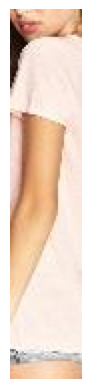


Caption: a woman in a black shirt and white pants



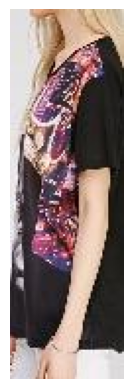


Caption: the back view of a woman wearing black and white skirt and white blouse



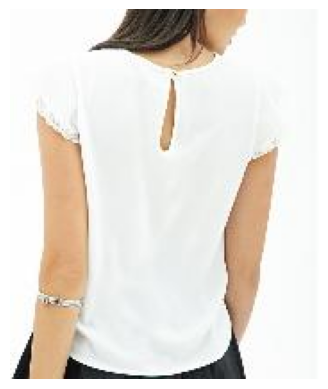


Caption: the back view of a woman wearing a red romper



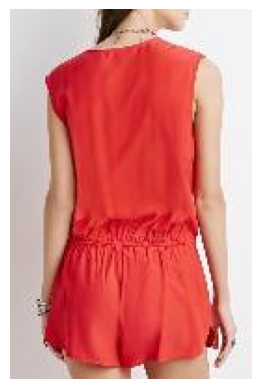


Caption: the back view of a woman wearing jeans and a black top



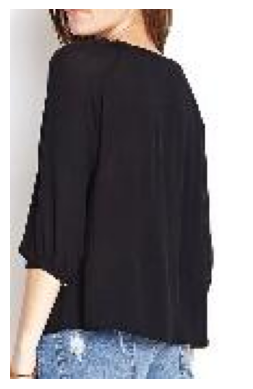

In [3]:
import random
from PIL import Image
import matplotlib.pyplot as plt

samples = random.sample(list(captions.items()), 5)

for path, caption in samples:
    print("\nCaption:", caption)
    
    img = Image.open(path)
    plt.imshow(img)
    plt.axis("off")
    plt.show()

In [4]:
import json
from collections import Counter
import numpy as np

# Load captions
with open("/kaggle/working/captions.json", "r") as f:
    captions = json.load(f)

texts = list(captions.values())

# ---------------- BASIC STATS ---------------- #

total = len(texts)

lengths = [len(t.split()) for t in texts]

empty = sum(1 for t in texts if t.strip() == "")
very_short = sum(1 for t in texts if len(t.split()) <= 2)

avg_len = np.mean(lengths)
max_len = max(lengths)
min_len = min(lengths)

print("Total captions:", total)
print("Empty captions:", empty)
print("Very short captions:", very_short)
print("Average length:", round(avg_len, 2))
print("Min length:", min_len)
print("Max length:", max_len)


# ---------------- DUPLICATES ---------------- #

unique_captions = len(set(texts))
duplicate_ratio = 1 - (unique_captions / total)

print("\nUnique captions:", unique_captions)
print("Duplicate ratio:", round(duplicate_ratio, 3))


# ---------------- VOCABULARY ---------------- #

all_words = []
for t in texts:
    all_words.extend(t.lower().split())

vocab = set(all_words)

print("\nVocabulary size:", len(vocab))


# ---------------- COMMON WORDS ---------------- #

counter = Counter(all_words)

print("\nTop 10 most common words:")
for word, count in counter.most_common(10):
    print(word, ":", count)


# ---------------- SUSPICIOUS WORD CHECK ---------------- #

suspicious_words = ["baby", "dog", "food", "car", "tree"]

suspicious_count = sum(
    any(word in t.lower() for word in suspicious_words)
    for t in texts
)

print("\nSuspicious captions:", suspicious_count)

Total captions: 19999
Empty captions: 0
Very short captions: 0
Average length: 9.81
Min length: 3
Max length: 20

Unique captions: 13579
Duplicate ratio: 0.321

Vocabulary size: 1354

Top 10 most common words:
a : 32642
and : 13529
woman : 11504
the : 10894
in : 9116
black : 7340
top : 6889
white : 6837
wearing : 5753
is : 4715

Suspicious captions: 614
